# Partition size distribution — optimized DP2 builds

Explores the partitioning of three size-optimized `hats-import` builds of DP2 object
data (partial-sky test regions under `/sdf/data/rubin/user/olynn/mem_size_dp2/`), with
**Gaia DR3** kept as the benchmark catalog throughout.

| catalog | partitions | rows | sky fraction | orders |
|---|---|---|---|---|
| optimized_0 | 271 | 10.4M | 0.23% | 4–8 |
| optimized_1 | 118 | 12.6M | 1.11% | 3–7 |
| optimized_2 | 294 | 54.8M | 0.99% | 4–6 |

All three ship a parquet `_metadata` index (unlike the earlier DP2 builds), so
per-partition row counts and byte sizes come from a single read — no `os.walk` and no
slow per-file `os.stat` sweeps.

In [1]:
import logging
import os
import re
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from human_readable import file_size
from hats import read_hats
from cdshealpix import healpix_to_lonlat  # NESTED; same lib hats uses internally

# Quiet the console: silence third-party DEBUG/INFO logs (the root logger is at
# DEBUG) and the benign hats "HEALPix pixels smaller than a plot pixel" warning,
# so cell output is just the figures + the comparison table.
for _noisy in ("matplotlib", "numexpr", "PIL"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="This plot contains HEALPix pixels smaller")

%matplotlib inline

# User preference: big labels by default.
plt.rcParams.update({"font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14})

BINS = 30  # number of histogram bins

# Shared cache dir for the per-partition size scans (only Gaia's ~2k os.stat
# calls are slow enough to matter; the optimized builds have ~120-300 files).
CACHE_DIR = os.path.join(os.getcwd(), ".partition_cache")

MEM_ROOT = "/sdf/data/rubin/user/olynn/mem_size_dp2"
CATALOGS = {
    "optimized_0": f"{MEM_ROOT}/optimized_0/optimized_0",
    "optimized_1": f"{MEM_ROOT}/optimized_1/optimized_1",
    "optimized_2": f"{MEM_ROOT}/optimized_2/optimized_2",
}
GAIA = "/sdf/data/rubin/cosmicdata/lsdb/gaia_dr3/gaia"  # benchmark

In [2]:
_PIX = re.compile(r"Norder=(\d+)/Dir=\d+/Npix=(\d+)")


def _pixel_path(cat_dir, order, npix):
    """On-disk parquet path for a HATS partition (Dir = floor(Npix/10000)*10000)."""
    return f"{cat_dir}/dataset/Norder={order}/Dir={(npix // 10000) * 10000}/Npix={npix}.parquet"


def partition_sizes(cat_dir, cache=True):
    """(order, npix, size_bytes) per partition, via the read_hats pixel list (reads
    partition_info.csv only) + os.stat of each partition's deterministic path.
    Stat-ing by pixel path (rather than os.walk) keeps `_metadata`, the skymaps and
    `data_thumbnail.parquet` out of the numbers. Cached to
    `.partition_cache/*.sizes.npz`; only Gaia's ~2k files are slow cold.
    """
    ckey = os.path.join(CACHE_DIR, cat_dir.strip("/").replace("/", "__") + ".sizes.npz")
    if cache and os.path.exists(ckey):
        d = np.load(ckey)
        return d["order"], d["npix"], d["size"]
    pix = read_hats(cat_dir).get_healpix_pixels()
    order = np.array([p.order for p in pix], dtype=np.uint8)
    npix = np.array([p.pixel for p in pix], dtype=np.uint64)
    size = np.array(
        [os.path.getsize(_pixel_path(cat_dir, int(o), int(p))) for o, p in zip(order, npix)],
        dtype=np.int64,
    )
    if cache:
        os.makedirs(CACHE_DIR, exist_ok=True)
        np.savez(ckey, order=order, npix=npix, size=size)
    return order, npix, size


def partition_frame(cat_dir, cache=True):
    """Per-partition (order, npix, rows, mb) for a HATS catalog — all int64/float64.

    Fast path: read the parquet ``_metadata`` index and aggregate row-group
    ``num_rows`` + ``total_byte_size`` (uncompressed) per file — Gaia and all three
    optimized builds ship one. Fallback for catalogs without it: ``os.stat`` each
    partition file for its on-disk *compressed* bytes; row count is left NaN.
    Cached to ``.partition_cache/*.npz``.
    """
    key = cat_dir.strip("/").replace("/", "__") + ".npz"
    cpath = os.path.join(CACHE_DIR, key)
    if cache and os.path.exists(cpath):
        d = np.load(cpath)
        return d["order"], d["npix"], d["rows"], d["mb"]

    meta = f"{cat_dir}/dataset/_metadata"
    if os.path.exists(meta):
        md = pq.read_metadata(meta)
        rows, byt = defaultdict(float), defaultdict(float)
        for i in range(md.num_row_groups):
            rg = md.row_group(i)
            f = rg.column(0).file_path
            rows[f] += rg.num_rows
            byt[f] += rg.total_byte_size  # uncompressed in-memory size
        order, npix, rr, mb = [], [], [], []
        for f in rows:
            o, n = _PIX.search(f).groups()
            order.append(int(o)); npix.append(int(n))
            rr.append(rows[f]);   mb.append(byt[f] / 1e6)
    else:
        pix = read_hats(cat_dir).get_healpix_pixels()
        order = [p.order for p in pix]
        npix = [p.pixel for p in pix]
        rr = [np.nan] * len(pix)
        mb = [os.path.getsize(_pixel_path(cat_dir, o, n)) / 1e6 for o, n in zip(order, npix)]

    order = np.asarray(order, np.int64)
    npix = np.asarray(npix, np.int64)
    rr = np.asarray(rr, float)
    mb = np.asarray(mb, float)
    if cache:
        os.makedirs(CACHE_DIR, exist_ok=True)
        np.savez(cpath, order=order, npix=npix, rows=rr, mb=mb)
    return order, npix, rr, mb


def partition_arrow_mb(cat_dir, cache=True):
    """(order, npix, mb) per partition, where mb is the EXACT in-memory size of the
    fully-decoded partition as a pyarrow Table (``Table.nbytes``) — the ground truth
    for a 1 GB in-memory partition budget. Parquet's ``total_byte_size`` understates
    this by ~1.5-2.3x on these catalogs (nested light-curve columns encode compactly).

    First run reads every parquet in full (~93 GB across the three optimized builds,
    minutes on NFS) — cached to ``.partition_cache/*.arrow.npz``, so it's slow once.
    """
    ckey = os.path.join(CACHE_DIR, cat_dir.strip("/").replace("/", "__") + ".arrow.npz")
    if cache and os.path.exists(ckey):
        d = np.load(ckey)
        return d["order"], d["npix"], d["mb"]
    pix = read_hats(cat_dir).get_healpix_pixels()
    order = np.array([p.order for p in pix], np.int64)
    npix = np.array([p.pixel for p in pix], np.int64)
    mb = np.array(
        [pq.read_table(_pixel_path(cat_dir, int(o), int(p))).nbytes / 1e6
         for o, p in zip(order, npix)],
        float,
    )
    if cache:
        os.makedirs(CACHE_DIR, exist_ok=True)
        np.savez(ckey, order=order, npix=npix, mb=mb)
    return order, npix, mb


def plot_partition_hist(name, cat_dir):
    """Histogram of on-disk parquet bytes per partition."""
    _, _, size = partition_sizes(cat_dir)
    mb = size / 1e6

    fig, ax = plt.subplots(figsize=(10, 6))
    counts, edges, _ = ax.hist(mb, bins=BINS, color="#4C72B0", edgecolor="white")

    ax.set_xlabel("Partition file size (MB)")
    ax.set_ylabel("Number of partitions")
    ax.set_title(
        f"{name}: partition size distribution\n"
        f"{len(mb):,} partitions, {file_size(int(size.sum()))} total, "
        f"median {np.median(mb):.0f} MB",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.3)

    if len(counts):
        peak = counts.argmax()
        ax.annotate(
            f"{int(counts[peak]):,} partitions",
            xy=((edges[peak] + edges[peak + 1]) / 2, counts[peak]),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            color="#333333",
        )

    fig.tight_layout()
    plt.show()

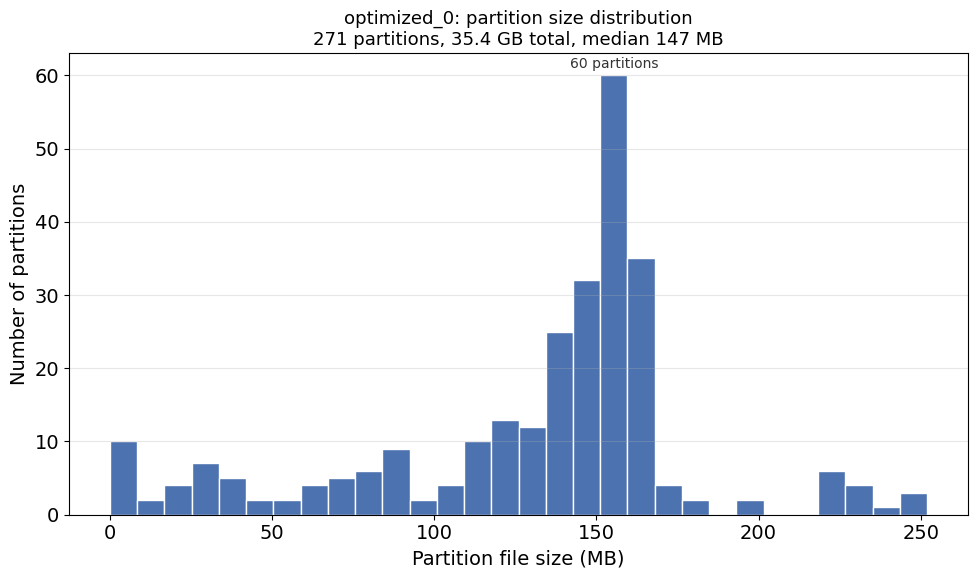

In [3]:
plot_partition_hist("optimized_0", CATALOGS["optimized_0"])

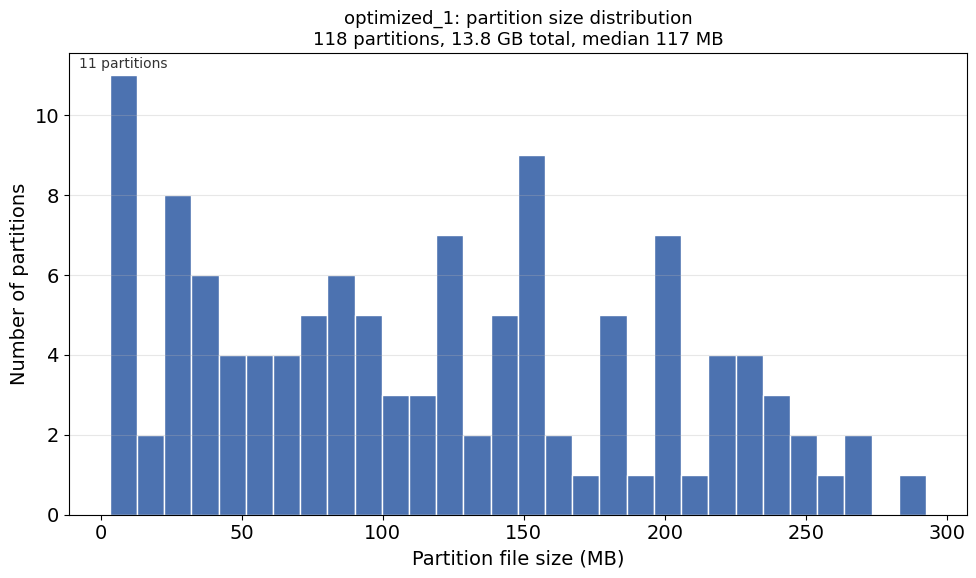

In [4]:
plot_partition_hist("optimized_1", CATALOGS["optimized_1"])

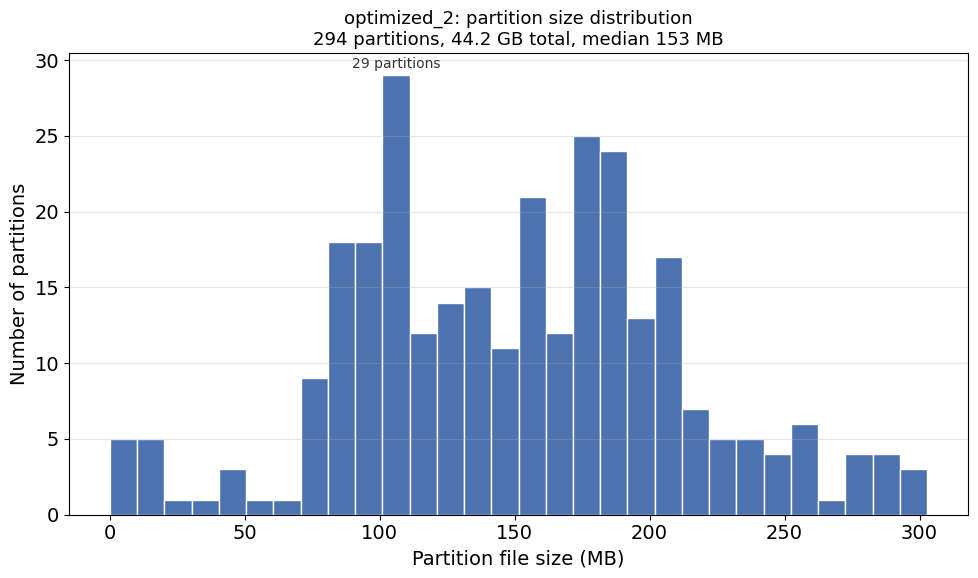

In [5]:
plot_partition_hist("optimized_2", CATALOGS["optimized_2"])

# Where partition-size extremes sit on the sky

For each catalog, overplot the sky positions of the **20 largest** and **20 smallest**
partitions (these builds have only ~120–300 partitions total, so the old N=100 would be
most of the catalog). Partitions are HEALPix pixels `(Norder, Npix)`; the pixel list comes
from `hats.read_hats(...).get_healpix_pixels()` (reads `partition_info.csv` only) and
per-partition size is the parquet file size, `stat`'d directly by pixel path.

The footprints cover ≲1% of the sky, so instead of a full-sky Mollweide the scatter is
drawn on RA/Dec axes centred on the footprint (RA re-centred so the optimized_2 region,
which straddles RA = 0°, stays contiguous). Grey points are the remaining partitions.
For the idiomatic tile renderer see the **Native partition maps** section below.

In [6]:
N_EXTREME = 20
C_SMALL, C_LARGE = "#4C72B0", "#C44E52"


def _centers_deg(order, npix):
    """HEALPix pixel centers (NESTED) -> (ra, dec) in degrees."""
    lon, lat = healpix_to_lonlat(np.asarray(npix, np.uint64), np.asarray(order, np.uint8))
    return lon.deg % 360.0, lat.deg


def plot_extremes_on_sky(name, cat_dir, n=N_EXTREME):
    order, npix, size = partition_sizes(cat_dir)
    idx = np.argsort(size)
    small, large = idx[:n], idx[-n:]

    ra, dec = _centers_deg(order, npix)
    # Centre the footprint in RA via the circular mean (handles the optimized_2
    # region straddling RA = 0).
    ra0 = np.degrees(np.arctan2(np.sin(np.radians(ra)).mean(),
                                np.cos(np.radians(ra)).mean())) % 360.0
    dra = ((ra - ra0 + 180) % 360) - 180

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.scatter(dra, dec, s=14, c="#BBBBBB", zorder=2,
               label=f"other partitions ({len(size):,} total)")
    ax.scatter(dra[small], dec[small], s=70, c=C_SMALL, edgecolor="white", lw=0.4, zorder=3,
               label=f"{n} smallest  (≤ {file_size(int(size[small].max()))})")
    ax.scatter(dra[large], dec[large], s=80, c=C_LARGE, marker="D", edgecolor="white",
               lw=0.4, zorder=4,
               label=f"{n} largest  (≥ {file_size(int(size[large].min()))})")
    ax.set_xlabel(f"RA − {ra0:.0f}°  [deg]")
    ax.set_ylabel("Dec  [deg]")
    ax.set_title(f"{name}: partition-size extremes on sky  ({len(size):,} partitions)")
    ax.invert_xaxis()  # RA increases to the left, as on sky
    ax.grid(alpha=0.3)
    ax.legend(loc="best", framealpha=0.9)
    fig.tight_layout()
    plt.show()

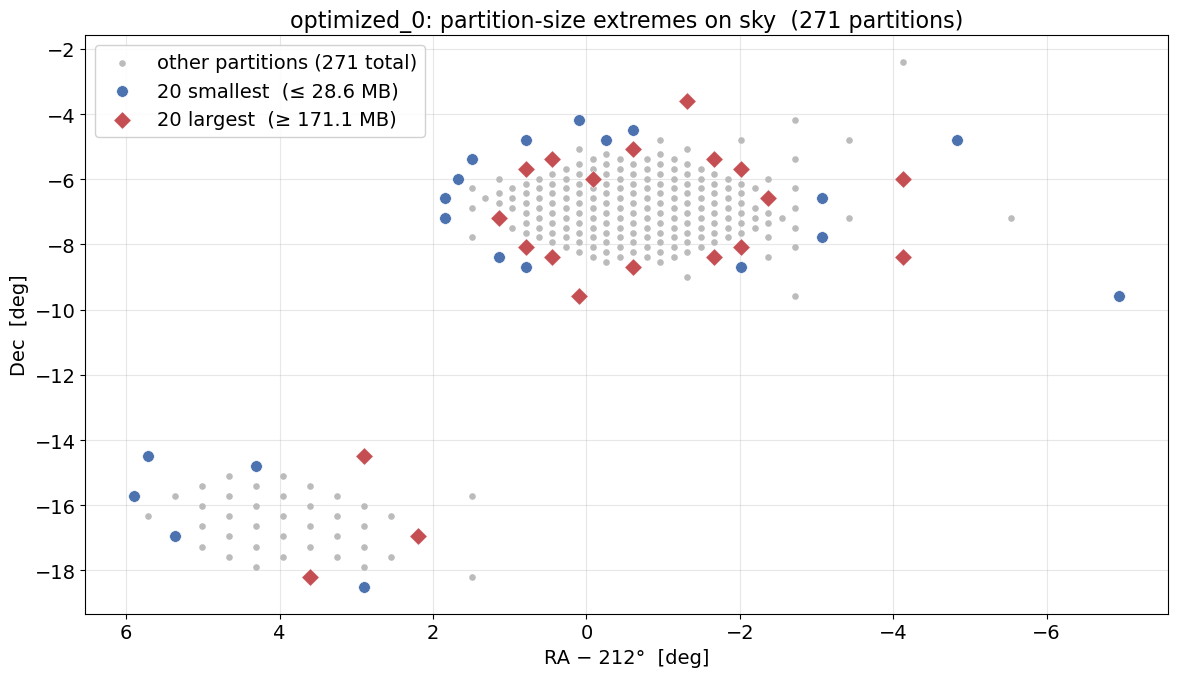

In [7]:
plot_extremes_on_sky("optimized_0", CATALOGS["optimized_0"])

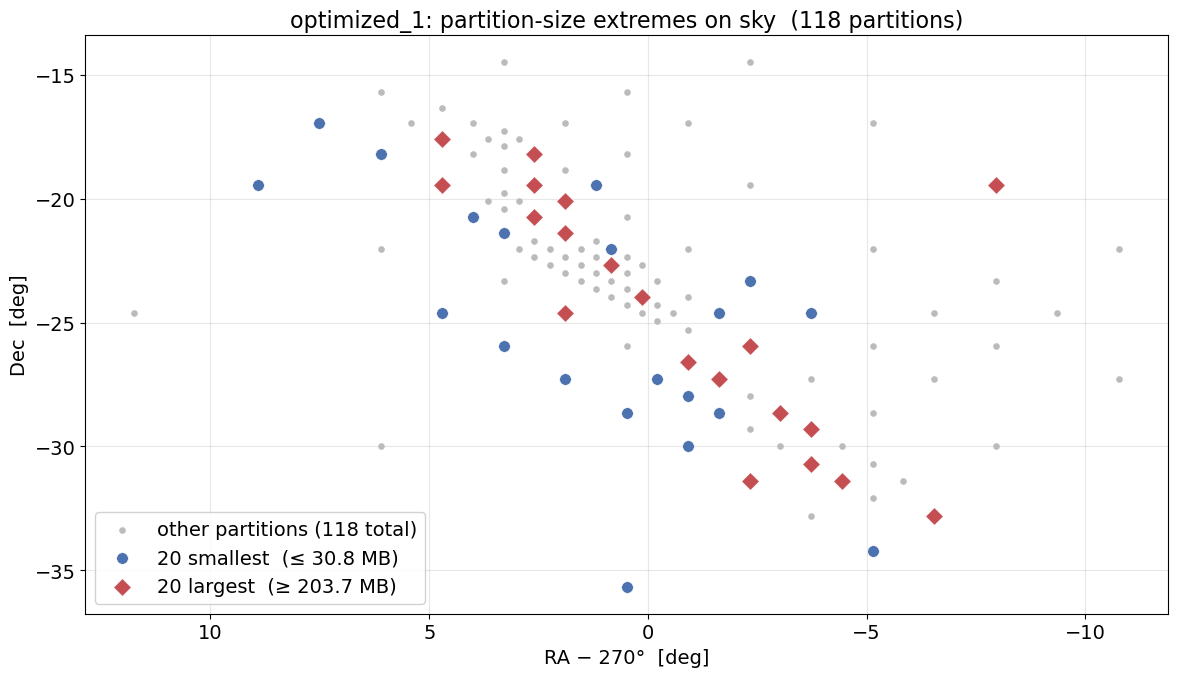

In [8]:
plot_extremes_on_sky("optimized_1", CATALOGS["optimized_1"])

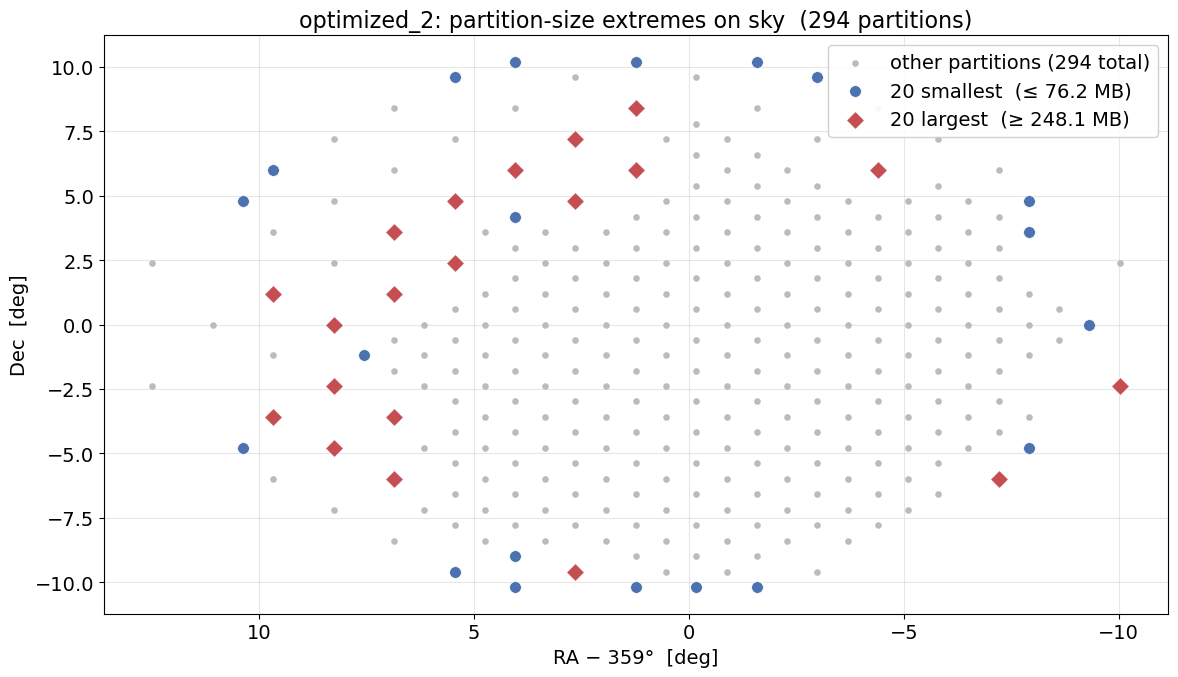

In [9]:
plot_extremes_on_sky("optimized_2", CATALOGS["optimized_2"])

# Native partition maps (tile renderer) + Gaia comparison

This section uses the idiomatic **`plot_healpix_map`** tile renderer (real HEALPix cells
coloured by a value array). The hats#703 crash is `uint64`-specific — feeding
`ipix`/`depth` as **int64** avoids it entirely.

All four catalogs ship a parquet **`_metadata`** index, so every partition's row count
*and* byte size come from a single read (~7 s cold for Gaia, instant for the small
optimized builds; results are cached to `.partition_cache/*.npz`). The optimized maps are
coloured by **true row counts**. Note the builds' `hats_max_rows = 1,000,000` cap is not
what binds — no partition exceeds ~558k rows; the **1 GB in-memory size target** is the
active constraint.

Gaia is full-sky and drawn on a Mollweide; the optimized footprints cover ≲1% of the sky,
so their maps auto-zoom to the footprint (gnomonic/TAN projection, centre and field of
view derived from the pixel centers — RA-wrap safe).

In [10]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from hats.inspection.visualize_catalog import plot_healpix_map


def _footprint_zoom(order, npix, pad=1.4):
    """(center SkyCoord, fov Quantity) enclosing the pixel centers, or (None, None)
    for near-full-sky footprints. The unit-vector mean centre handles footprints
    that straddle RA = 0 (optimized_2)."""
    ra, dec = _centers_deg(order, npix)
    ra_r, dec_r = np.radians(ra), np.radians(dec)
    v = np.column_stack([np.cos(dec_r) * np.cos(ra_r),
                         np.cos(dec_r) * np.sin(ra_r),
                         np.sin(dec_r)]).mean(axis=0)
    v /= np.linalg.norm(v)
    cen = SkyCoord(ra=np.degrees(np.arctan2(v[1], v[0])) % 360 * u.deg,
                   dec=np.degrees(np.arcsin(v[2])) * u.deg)
    sep = cen.separation(SkyCoord(ra=ra * u.deg, dec=dec * u.deg)).deg.max()
    if sep > 45:
        return None, None  # too wide to zoom sensibly — keep the Mollweide view
    return cen, 2 * pad * sep * u.deg


def plot_partition_map(name, cat_dir, by="rows", cmap="viridis", mark=None):
    """Tile map of a HATS catalog coloured by per-partition row count or size (MB).
    Small footprints are auto-zoomed (TAN projection); full-sky catalogs use
    Mollweide. `mark=(order, npix)` overlays that HEALPix pixel as a red tile
    square to locate a region of interest on the sky.
    """
    order, npix, rows, mb = partition_frame(cat_dir)
    if by == "rows" and np.isfinite(rows).any():
        values, unit = rows, "rows / partition"
    else:
        values, unit = mb, "MB / partition"

    cen, fov = _footprint_zoom(order, npix)
    if cen is None:
        fig, ax = plot_healpix_map(values, ipix=npix, depth=order, projection="MOL", cmap=cmap)
    else:
        fig, ax = plot_healpix_map(values, ipix=npix, depth=order, projection="TAN",
                                   center=cen, fov=fov, cmap=cmap)
    ax.set_title(f"{name}: {unit}   ({len(values):,} partitions, orders "
                 f"{order.min()}-{order.max()})", pad=18)

    if mark is not None:
        from cdshealpix.nested import vertices
        mo, mp = mark
        tr = ax.get_transform("world")
        vlon, vlat = vertices(np.array([mp], np.uint64), np.uint8(mo))
        vx = np.append(np.array(vlon.deg)[0], np.array(vlon.deg)[0][0])
        vy = np.append(np.array(vlat.deg)[0], np.array(vlat.deg)[0][0])
        ax.fill(vx, vy, transform=tr, facecolor="red", edgecolor="red", lw=2.0,
                alpha=0.6, zorder=10, label=f"merge example (order {mo}, npix {mp})")
        ax.legend(loc="lower right")

    plt.show()
    return order, npix, rows, mb

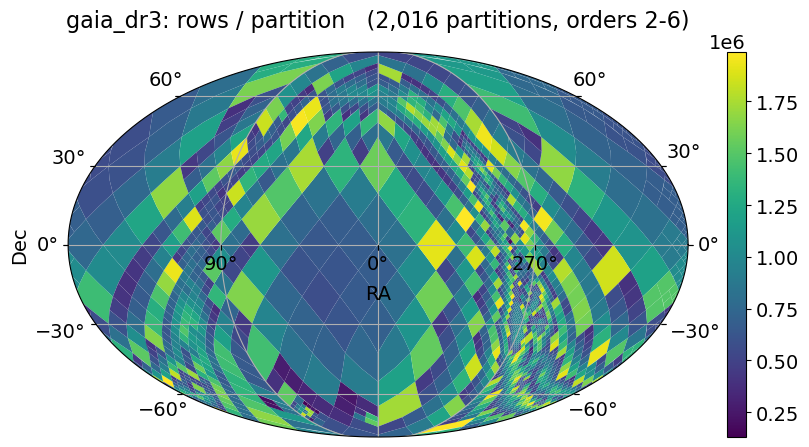

In [11]:
# Gaia DR3 benchmark — full sky, coloured by rows/partition (~7 s cold, instant cached).
_ = plot_partition_map("gaia_dr3", GAIA, by="rows")

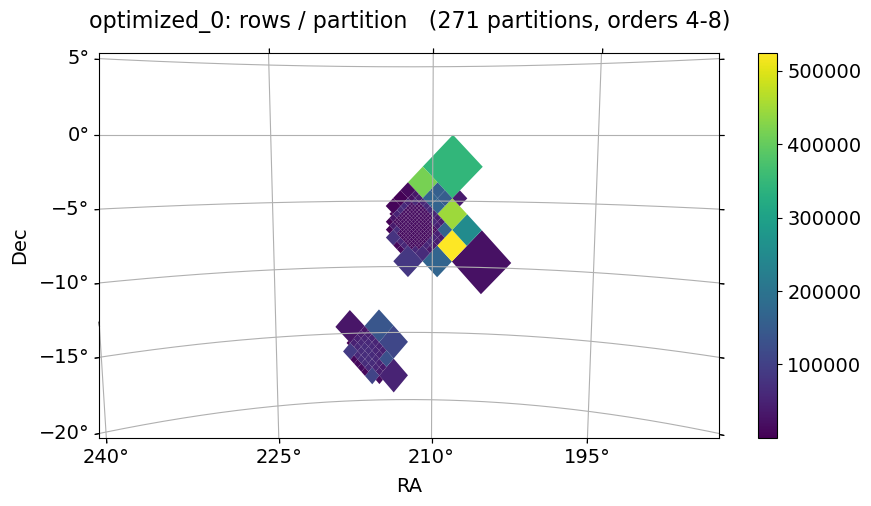

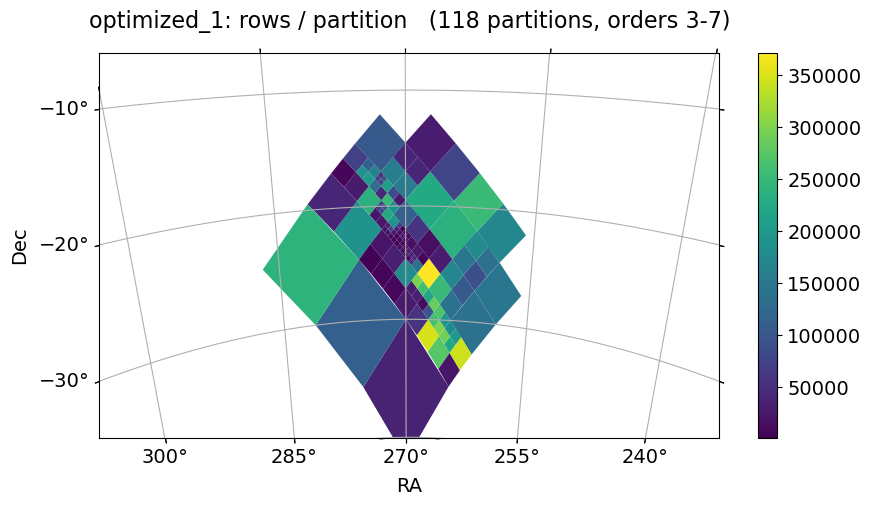

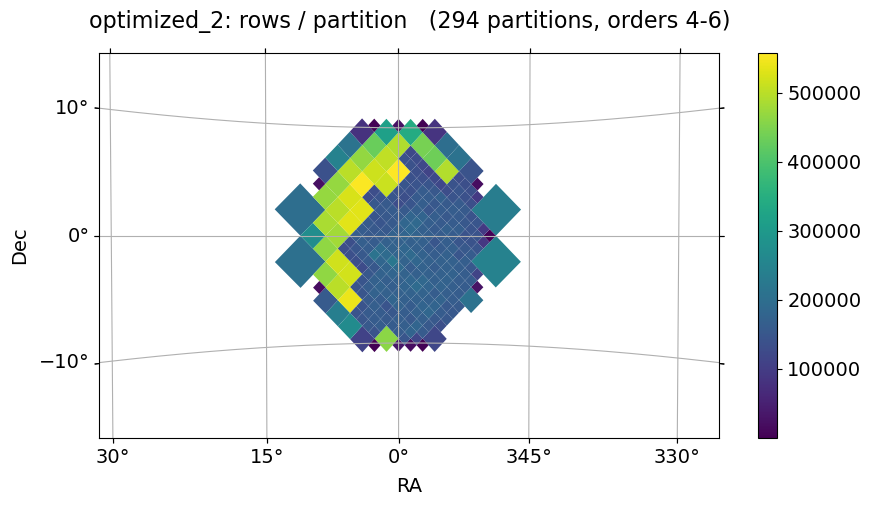

In [12]:
# Optimized builds — `_metadata` gives true row counts (the build target was
# hats_max_rows = 1,000,000); maps auto-zoom to each ~1%-sky footprint.
for name, path in CATALOGS.items():
    _ = plot_partition_map(name, path, by="rows")

# Gaia partition-size distribution (vs optimized builds)

Histogram of **on-disk parquet bytes per partition** for Gaia DR3, and PDF overlays
against the three optimized builds. Sizes come from `partition_sizes` (cached `os.stat`
of the deterministic partition paths) — **not** an `os.walk` of the dataset dir, which
would wrongly fold in `_metadata` (231 MB for Gaia), the skymaps, and
`data_thumbnail.parquet`. This makes the histograms directly comparable across catalogs.

Per catalog: dotted line = median, dashed line = max/4 — the size a partition would have
after one more HEALPix split (4 children), where an upper-edge dropoff is expected.

Headline: Gaia partitions are chunkier — median **335 MB** across **2,016** partitions,
vs ~**120–150 MB** medians across 118–294 partitions for the optimized builds. The
optimized builds' ~300 MB on-disk ceiling is the compressed shadow of their **1 GB
in-memory** target (they compress ~1.4–1.5× vs parquet-uncompressed, and arrow/pandas
in-memory footprints are larger still).

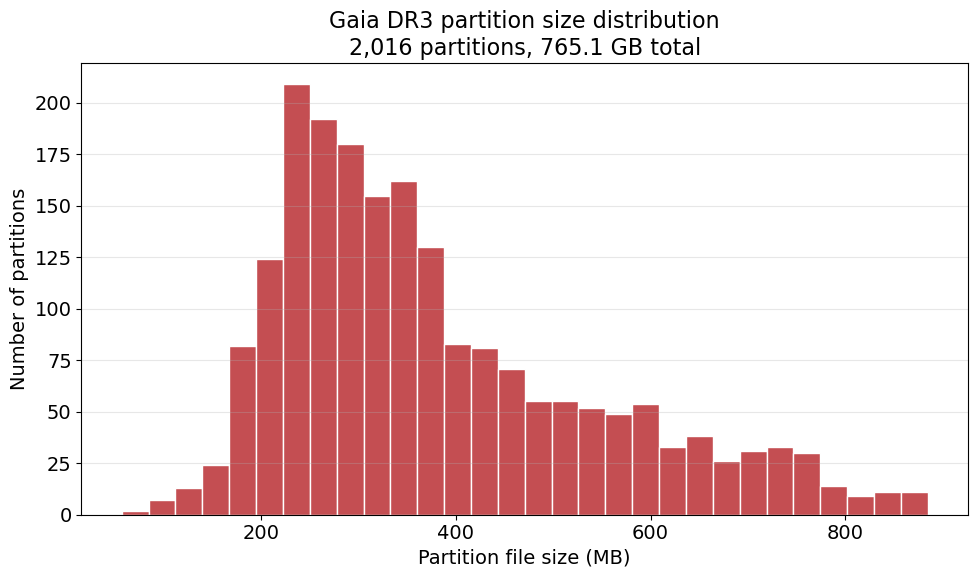

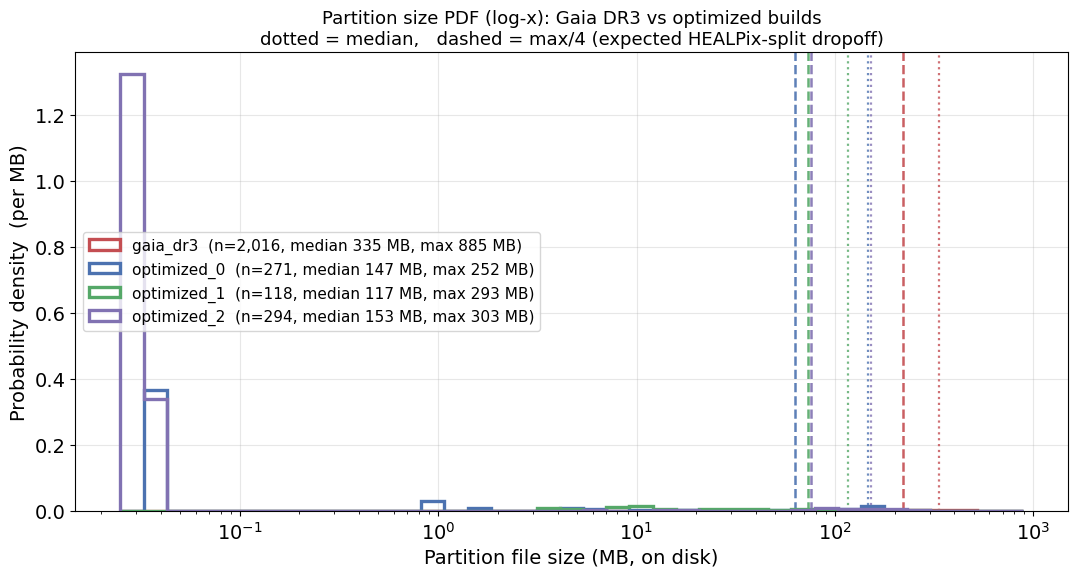

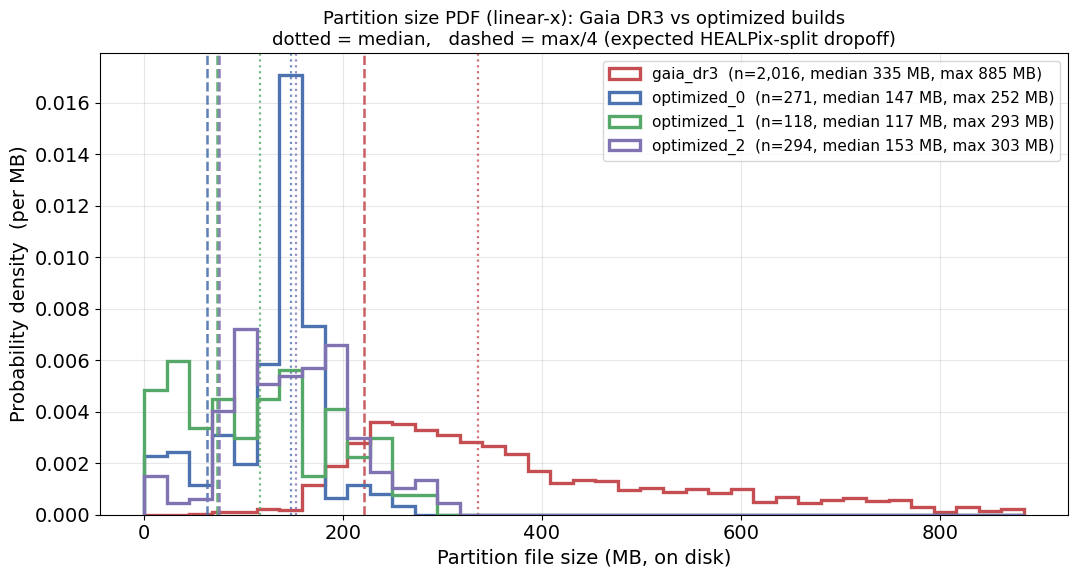

catalog                  n      total     median       mean        max      max/4
gaia_dr3             2,016   765.1 GB     335 MB     379 MB     885 MB     221 MB
optimized_0            271    35.4 GB     147 MB     131 MB     252 MB      63 MB
optimized_1            118    13.8 GB     117 MB     117 MB     293 MB      73 MB
optimized_2            294    44.2 GB     153 MB     150 MB     303 MB      76 MB


In [13]:
def _ondisk_mb(cat_dir):
    """On-disk parquet MB per partition (cached os.stat via partition_sizes)."""
    _, _, size = partition_sizes(cat_dir)
    return size / 1e6


gaia_mb = _ondisk_mb(GAIA)

# (1) Gaia on its own — same visual style as the optimized histograms at the top.
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(gaia_mb, bins=BINS, color="#C44E52", edgecolor="white")
ax.set_xlabel("Partition file size (MB)")
ax.set_ylabel("Number of partitions")
ax.set_title(f"Gaia DR3 partition size distribution\n"
             f"{len(gaia_mb):,} partitions, {file_size(int(gaia_mb.sum() * 1e6))} total")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# (2) Gaia vs the three optimized builds, as PDFs (density=True), in both log-x
# and linear-x. Per catalog: dotted line = median, dashed line = max/4 — the size
# a partition would have after one more HEALPix split (4 children).
overlay = {"gaia_dr3": gaia_mb}
overlay.update({name: _ondisk_mb(path) for name, path in CATALOGS.items()})
colors = {"gaia_dr3": "#C44E52", "optimized_0": "#4C72B0",
          "optimized_1": "#55A868", "optimized_2": "#8172B2"}


def _pdf_overlay(overlay, colors, xscale, bins):
    fig, ax = plt.subplots(figsize=(11, 6))
    for name, s in overlay.items():
        c = colors[name]
        ax.hist(s, bins=bins, density=True, histtype="step", lw=2.4, color=c,
                label=f"{name}  (n={len(s):,}, median {np.median(s):.0f} MB, max {s.max():.0f} MB)")
        ax.axvline(np.median(s), color=c, ls=":", lw=1.6, alpha=0.8)
        ax.axvline(s.max() / 4, color=c, ls="--", lw=1.8, alpha=0.9)
    ax.set_xscale(xscale)
    ax.set_xlabel("Partition file size (MB, on disk)")
    ax.set_ylabel("Probability density  (per MB)")
    ax.set_title(f"Partition size PDF ({xscale}-x): Gaia DR3 vs optimized builds\n"
                 "dotted = median,   dashed = max/4 (expected HEALPix-split dropoff)",
                 fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
    fig.tight_layout()
    plt.show()


allmb = np.concatenate(list(overlay.values()))
_pdf_overlay(overlay, colors, "log", np.logspace(np.log10(allmb.min()), np.log10(allmb.max()), 40))
_pdf_overlay(overlay, colors, "linear", np.linspace(0, allmb.max(), 40))

# (3) Comparison table.
print(f"{'catalog':16s} {'n':>9s} {'total':>10s} {'median':>10s} {'mean':>10s} {'max':>10s} {'max/4':>10s}")
for name, s in overlay.items():
    print(f"{name:16s} {len(s):>9,d} {file_size(int(s.sum() * 1e6)):>10s} "
          f"{np.median(s):>7.0f} MB {s.mean():>7.0f} MB {s.max():>7.0f} MB {s.max() / 4:>7.0f} MB")

# Partition size split by HEALPix order

If partitioning were a fixed-order grid, each step to a finer order would cut pixel area
(and therefore partition size) by 4×, so per-order size histograms would sit ~4× apart.
A **size/memory-targeted** builder instead picks a finer order exactly where the sky is
denser, so the ÷4 area step is cancelled by the ×4 density and every order lands in the
same byte-size band — flat per-order medians are its signature (Gaia shows this clearly
at ~270–395 MB across orders 2–6). The printed consecutive median ratios make the
comparison explicit: 4.0× = fixed-grid expectation, ~1× = perfectly size-targeted.

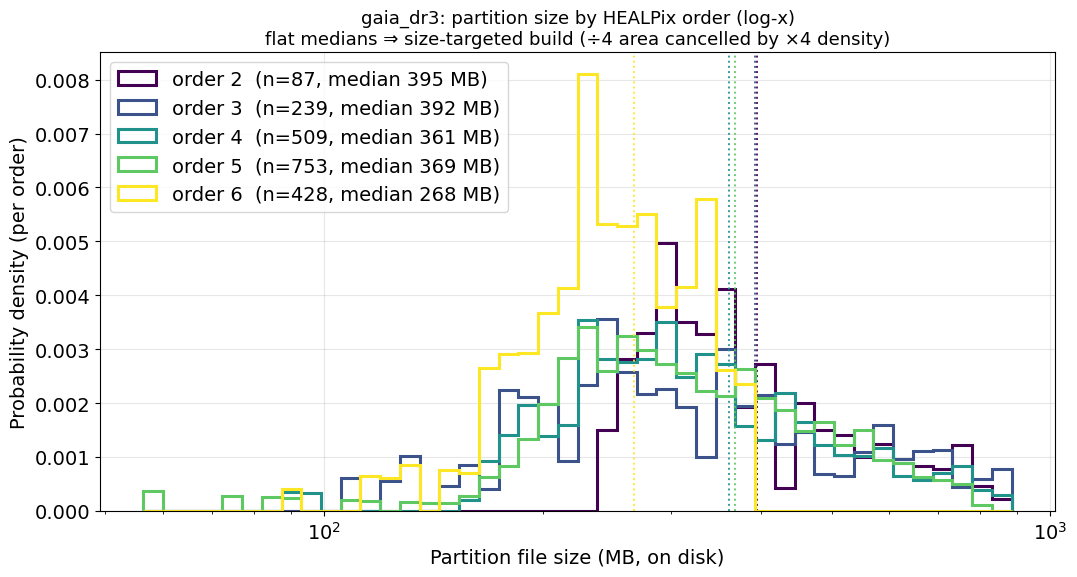

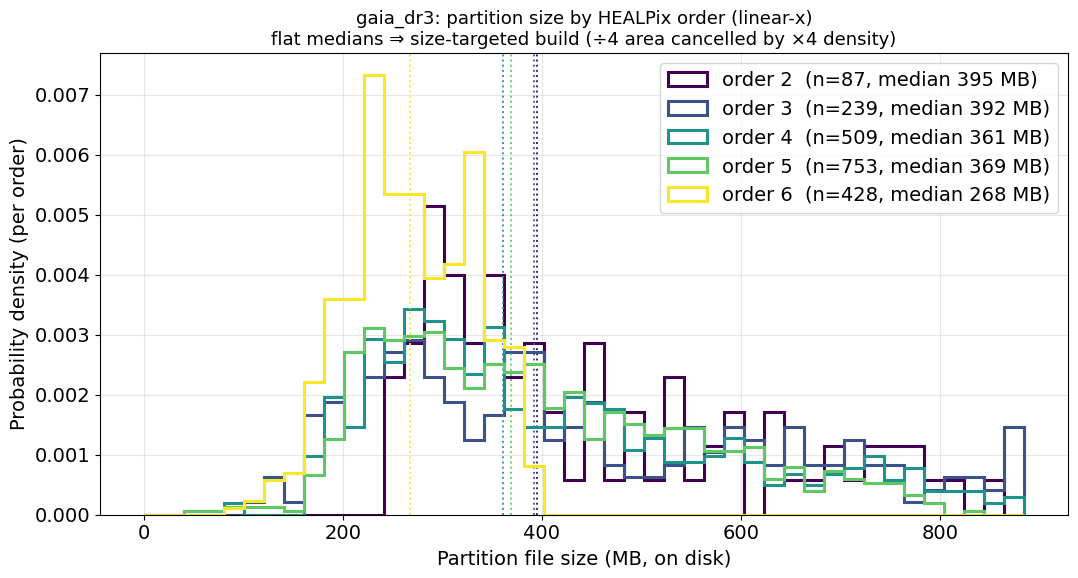

gaia_dr3: consecutive median ratios (order o / o+1) = 1.0x, 1.1x, 1.0x, 1.4x   (4.0x = fixed-grid expectation)


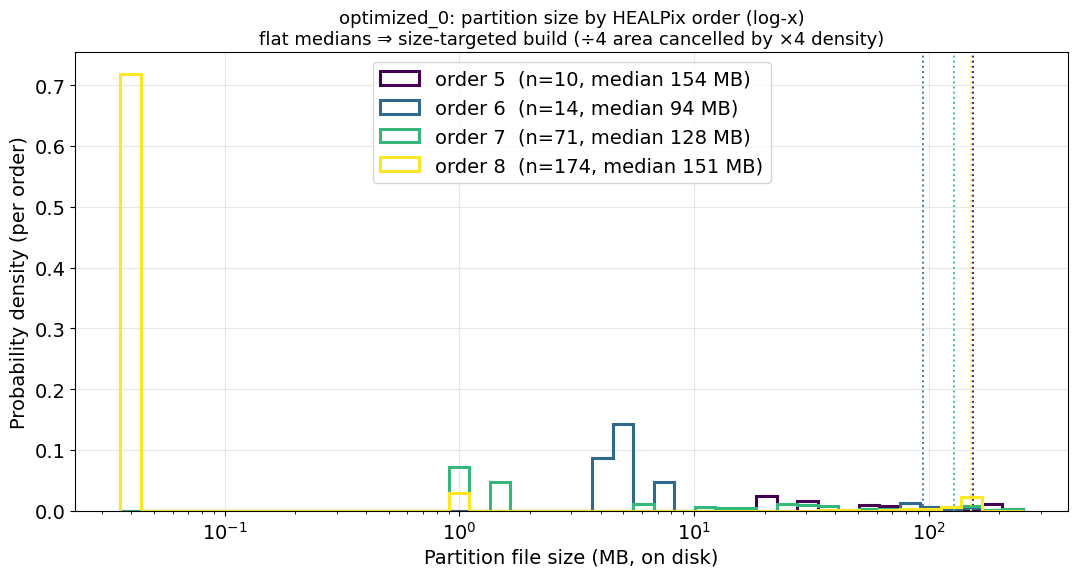

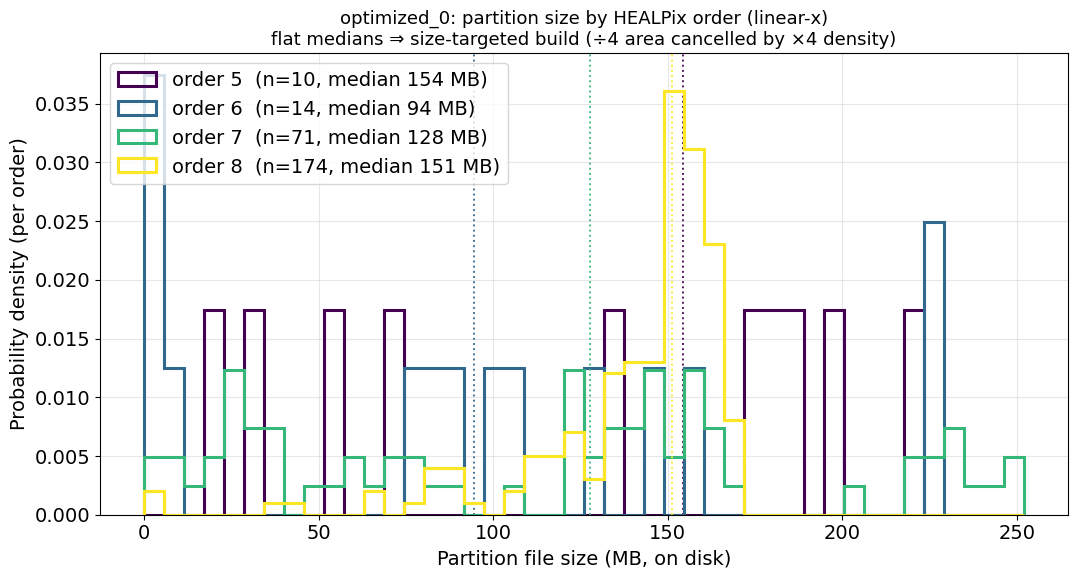

optimized_0: consecutive median ratios (order o / o+1) = 1.6x, 0.7x, 0.8x   (4.0x = fixed-grid expectation)


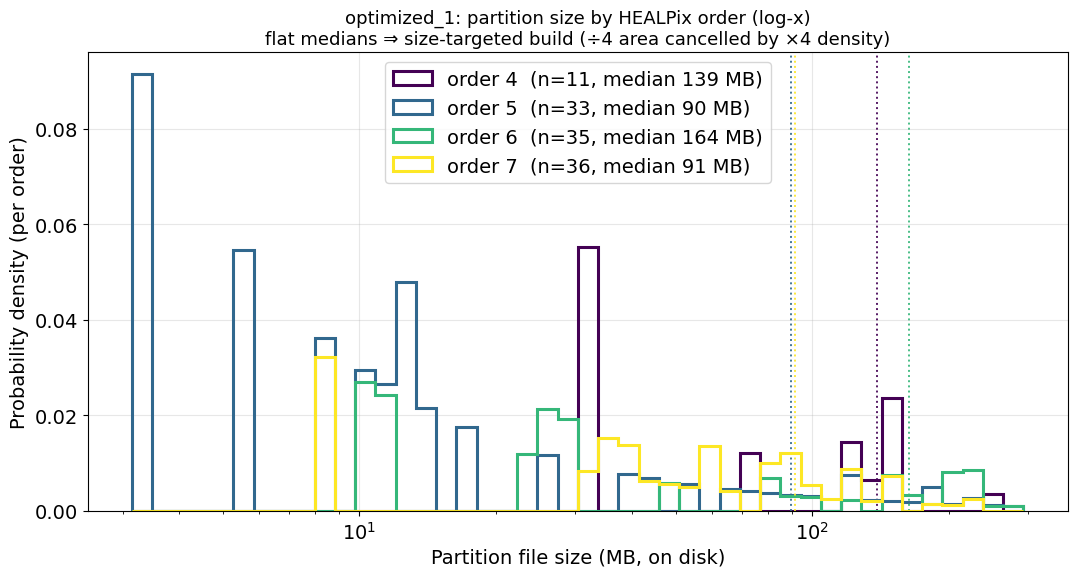

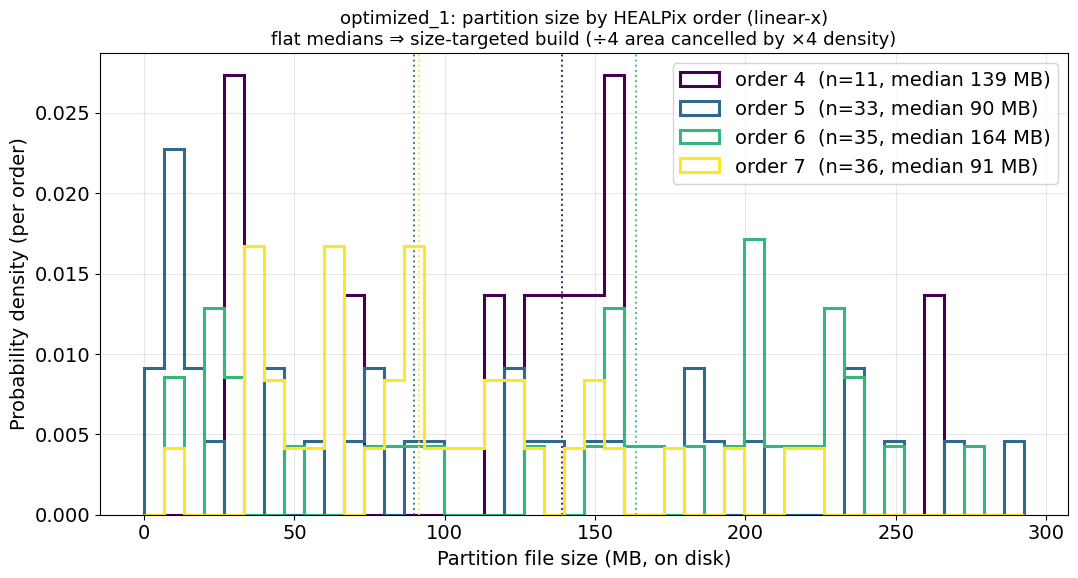

optimized_1: consecutive median ratios (order o / o+1) = 1.5x, 0.5x, 1.8x   (4.0x = fixed-grid expectation)


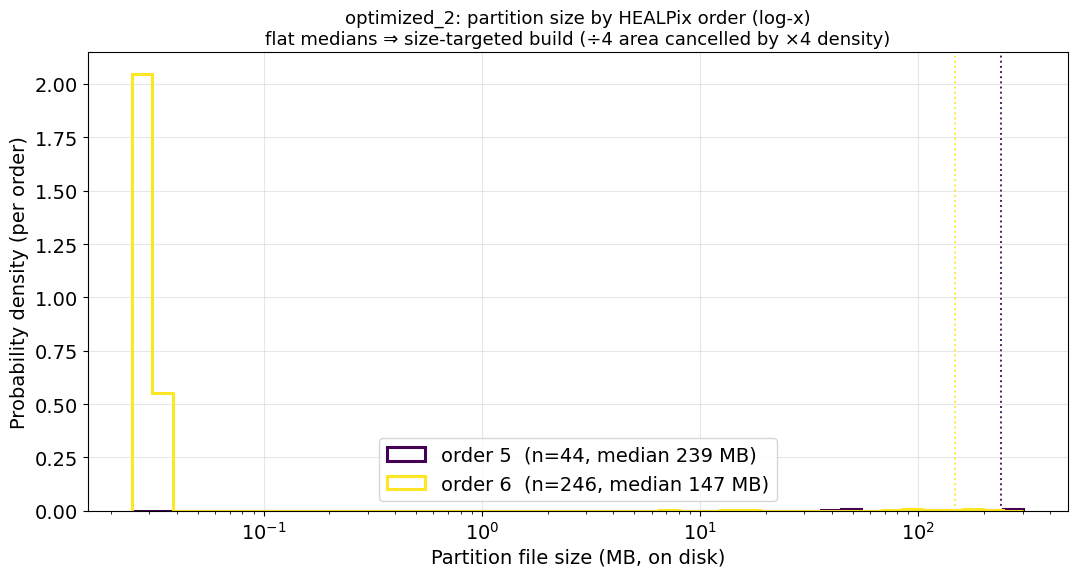

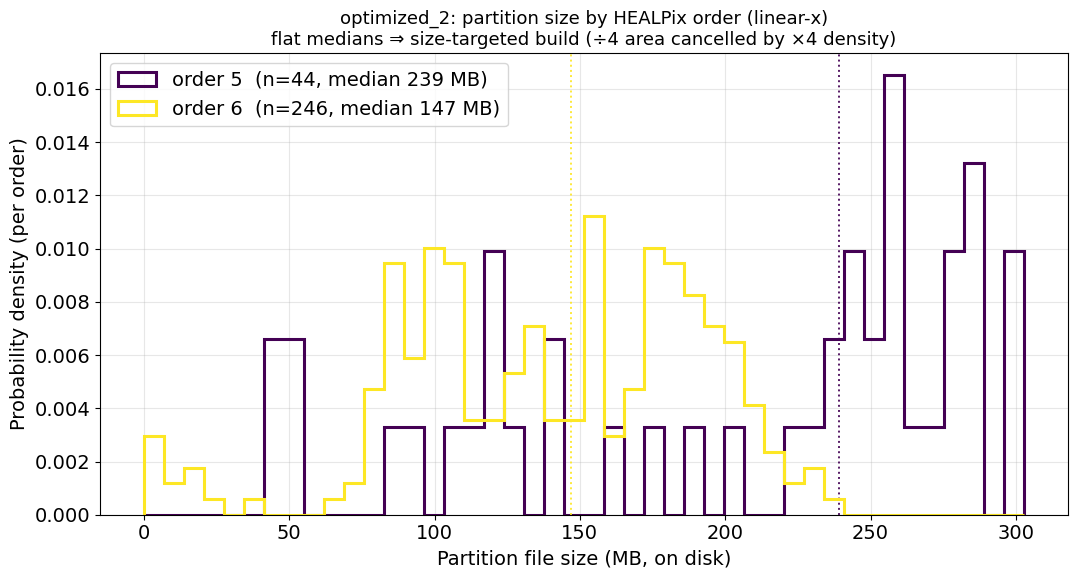

optimized_2: consecutive median ratios (order o / o+1) = 1.6x   (4.0x = fixed-grid expectation)


In [14]:
def plot_size_by_order(name, cat_dir, cmap="viridis", min_n=5, drop_orders=()):
    """Overlay per-HEALPix-order partition-size PDFs, in both log-x and linear-x.
    Dotted lines = per-order medians; a fixed-order grid would put them ~4x apart.
    Orders with fewer than `min_n` partitions are skipped as too noisy;
    `drop_orders` removes specific orders explicitly.
    """
    order, _, size = partition_sizes(cat_dir)
    mb = size / 1e6
    keep = ~np.isin(order, list(drop_orders))
    order, mb = order[keep], mb[keep]
    orders = [int(o) for o in np.unique(order) if (order == o).sum() >= min_n]
    cmo = plt.get_cmap(cmap)
    lo, hi = min(orders), max(orders)
    meds = {o: float(np.median(mb[order == o])) for o in orders}

    for xscale in ("log", "linear"):
        if xscale == "log":
            bins = np.logspace(np.log10(mb.min()), np.log10(mb.max()), 45)
        else:
            bins = np.linspace(0, mb.max(), 45)

        fig, ax = plt.subplots(figsize=(11, 6))
        for o in orders:
            s = mb[order == o]
            c = cmo((o - lo) / max(1, hi - lo))
            ax.hist(s, bins=bins, density=True, histtype="step", lw=2.2, color=c,
                    label=f"order {o}  (n={len(s):,}, median {meds[o]:.0f} MB)")
            ax.axvline(meds[o], color=c, ls=":", lw=1.4, alpha=0.9)
        ax.set_xscale(xscale)
        ax.set_xlabel("Partition file size (MB, on disk)")
        ax.set_ylabel("Probability density (per order)")
        dropped = f"  [orders {sorted(drop_orders)} dropped]" if drop_orders else ""
        ax.set_title(f"{name}: partition size by HEALPix order ({xscale}-x){dropped}\n"
                     "flat medians ⇒ size-targeted build (÷4 area cancelled by ×4 density)",
                     fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
        plt.show()

    ratios = ", ".join(f"{meds[orders[i]] / meds[orders[i + 1]]:.1f}x"
                       for i in range(len(orders) - 1))
    print(f"{name}: consecutive median ratios (order o / o+1) = {ratios}   (4.0x = fixed-grid expectation)")


plot_size_by_order("gaia_dr3", GAIA)
for name, path in CATALOGS.items():
    plot_size_by_order(name, path)

# Over-split partitions: what could be aggregated to a coarser order?

Using HEALPix nesting (a pixel's parent is `npix // 4`, one order coarser, NESTED), we roll
up every partition into its ancestor subtrees and find the **maximal** subtree whose combined
size stays **< 1000 MB** — the build's target maximum partition size, an **in-memory**
budget.

Sizes here are **exact in-memory sizes**: every partition is read in full and measured as a
decoded pyarrow Table (`Table.nbytes`, via `partition_arrow_mb`). This matters — parquet's
`total_byte_size` metadata understates arrow memory by ~1.5–2.3× on these catalogs (nested
light-curve columns encode compactly), and on-disk compressed bytes understate it further, so
proxy-based thresholds badly overstate mergeability. Summing children's `nbytes` is the right
merge estimate, since concatenating arrow tables is essentially exact.

(The first run reads ~93 GB and takes minutes; results are cached to
`.partition_cache/*.arrow.npz`.)

optimized_0: 271 partitions, threshold 1000 MB (arrow in-memory)
  4 maximal merge groups -> eliminate 12 partitions (4.4%) -> new count 259

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  6  npix      44755 :    4 -> 1   (   881 MB)
    order  7  npix     102870 :    4 -> 1   (   878 MB)
    order  6  npix      25894 :    4 -> 1   (   971 MB)
    order  6  npix      25716 :    4 -> 1   (   872 MB)


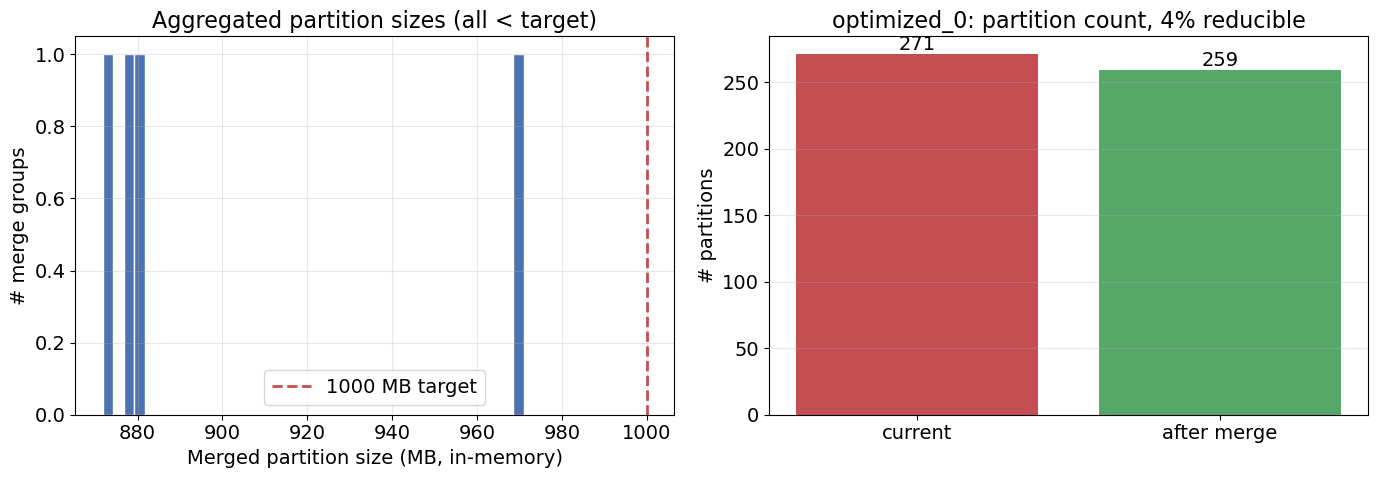

optimized_1: 118 partitions, threshold 1000 MB (arrow in-memory)
  3 maximal merge groups -> eliminate 9 partitions (7.6%) -> new count 109

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  6  npix      29091 :    4 -> 1   (   954 MB)
    order  6  npix      28916 :    4 -> 1   (   987 MB)
    order  6  npix      28913 :    4 -> 1   (   943 MB)


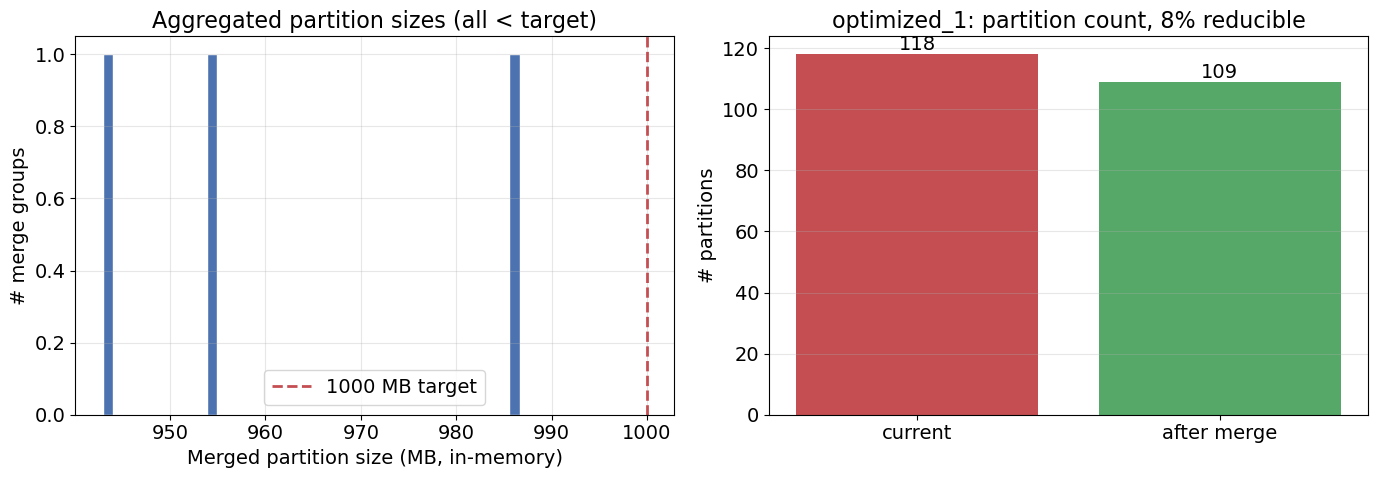

optimized_2: 294 partitions, threshold 1000 MB (arrow in-memory)
  10 maximal merge groups -> eliminate 28 partitions (9.5%) -> new count 266

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  5  npix       4515 :    4 -> 1   (   905 MB)
    order  5  npix       4521 :    4 -> 1   (   979 MB)
    order  5  npix       4325 :    4 -> 1   (   980 MB)
    order  5  npix       4875 :    4 -> 1   (   922 MB)
    order  5  npix       4315 :    4 -> 1   (   905 MB)
    order  5  npix       4868 :    4 -> 1   (   917 MB)
    order  5  npix       4514 :    4 -> 1   (   996 MB)
    order  5  npix       4318 :    4 -> 1   (   967 MB)
    order  5  npix       4878 :    4 -> 1   (   893 MB)
    order  5  npix       4332 :    2 -> 1   (   985 MB)


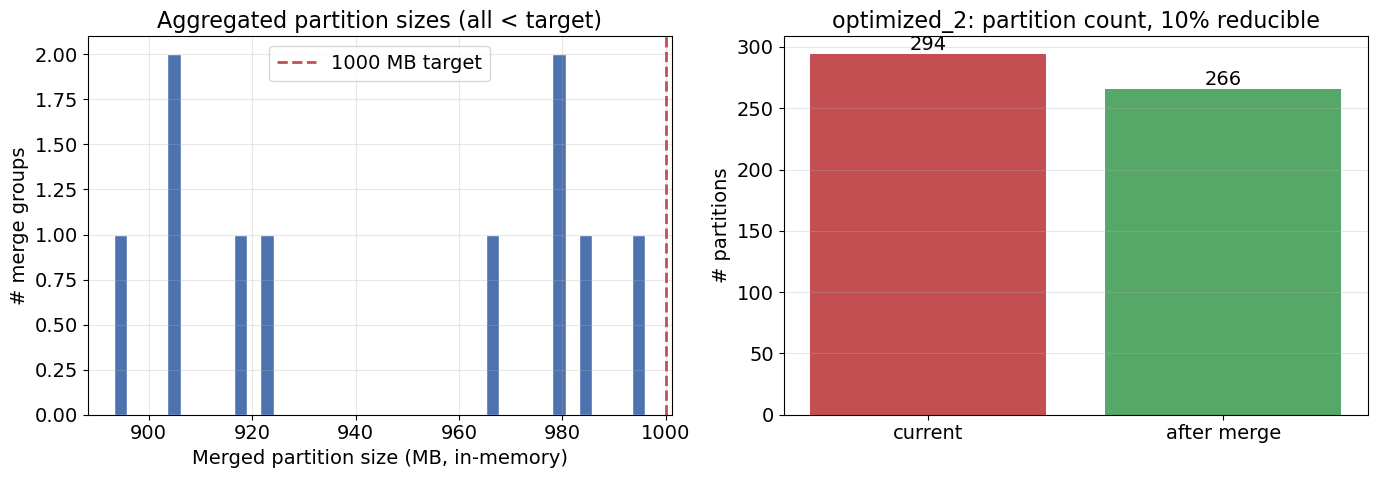

In [15]:
MERGE_THRESH_MB = 1000.0  # the build's target max partition size (in-memory);
                          # compared against EXACT arrow Table.nbytes per partition.


def merge_candidates(name, cat_dir, thresh_mb=MERGE_THRESH_MB, show=15, plot=True):
    """Find HEALPix subtrees that could collapse to a single coarser partition
    while staying < thresh_mb in memory (exact arrow sizes). Parent pixel =
    npix // 4 per order step (NESTED). Returns the *maximal* mergeable subtrees
    (coarsest ancestor still under threshold); prints a summary + examples and
    (optionally) plots.
    """
    order, npix, mb = partition_arrow_mb(cat_dir)  # mb = exact arrow in-memory MB
    maxo = int(order.max())

    # Roll each partition up into all its ancestors: subtree size + leaf count.
    total, leaves = defaultdict(float), defaultdict(int)
    for o, p, m in zip(order.astype(int), npix.astype(int), mb):
        total[(o, p)] += m
        leaves[(o, p)] += 1
    for o in range(maxo, 0, -1):
        for (oo, p) in [k for k in total if k[0] == o]:
            par = (o - 1, p >> 2)
            total[par] += total[(oo, p)]
            leaves[par] += leaves[(oo, p)]

    mergeable = {k for k, t in total.items() if leaves[k] > 1 and t < thresh_mb}
    # maximal = mergeable subtree whose own parent is NOT mergeable (avoid double counting)
    maximal = [k for k in mergeable if (k[0] - 1, k[1] >> 2) not in mergeable]
    saved = sum(leaves[k] - 1 for k in maximal)
    n = len(order)

    print(f"{name}: {n:,} partitions, threshold {thresh_mb:.0f} MB (arrow in-memory)")
    print(f"  {len(maximal):,} maximal merge groups -> eliminate {saved:,} partitions "
          f"({100 * saved / n:.1f}%) -> new count {n - saved:,}")
    maximal.sort(key=lambda k: leaves[k], reverse=True)
    print(f"\n  top {show} candidates (parent order/npix : #partitions -> 1, merged size):")
    for o, p in maximal[:show]:
        print(f"    order {o:>2d}  npix {p:>10d} : {leaves[(o, p)]:>4d} -> 1   ({total[(o, p)]:6.0f} MB)")

    if plot:
        merged = np.array([total[k] for k in maximal])
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
        a1.hist(merged, bins=40, color="#4C72B0", edgecolor="white")
        a1.axvline(thresh_mb, color="#C44E52", ls="--", lw=2, label=f"{thresh_mb:.0f} MB target")
        a1.set_xlabel("Merged partition size (MB, in-memory)")
        a1.set_ylabel("# merge groups")
        a1.set_title("Aggregated partition sizes (all < target)")
        a1.legend(); a1.grid(alpha=0.3)
        a2.bar(["current", "after merge"], [n, n - saved], color=["#C44E52", "#55A868"])
        for i, v in enumerate([n, n - saved]):
            a2.text(i, v, f"{v:,}", ha="center", va="bottom")
        a2.set_ylabel("# partitions")
        a2.set_title(f"{name}: partition count, {100 * saved / n:.0f}% reducible")
        a2.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        plt.show()

    return maximal, total, leaves


for name, path in CATALOGS.items():
    _ = merge_candidates(name, path)

## Aggregation depth — can you merge more than once?

The `merge_candidates` roll-up above already goes to **convergence**: it picks the *coarsest*
ancestor still under the 1 GB in-memory threshold, and since subtree size grows monotonically
up the tree, re-running the exercise finds nothing new. So "doing it twice" shows up not as a
second pass but as merge groups whose collapse spans **≥2 HEALPix order levels** (aggregation
depth = deepest child order − parent order).

The figure below shows each catalog's partition-size distribution (exact arrow in-memory MB)
before vs after aggregation.

optimized_0: aggregation depth (HEALPix levels collapsed):
   1 level(s): 4 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  6 npix     44755 : depth 1     4 -> 1  (  881 MB, child orders up to 7)
     order  7 npix    102870 : depth 1     4 -> 1  (  878 MB, child orders up to 8)
     order  6 npix     25894 : depth 1     4 -> 1  (  971 MB, child orders up to 7)
     order  6 npix     25716 : depth 1     4 -> 1  (  872 MB, child orders up to 7)


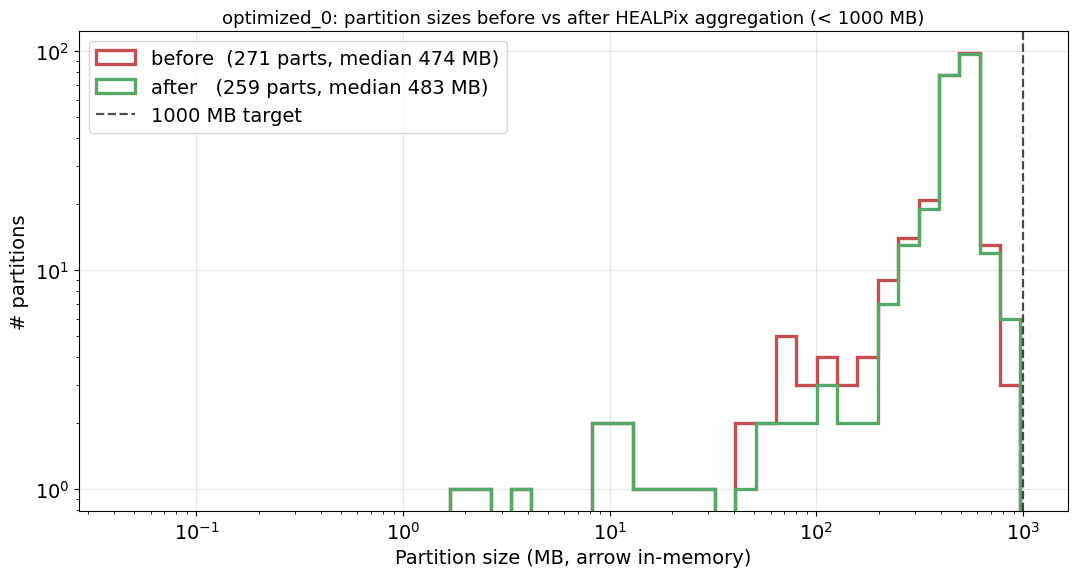

optimized_1: aggregation depth (HEALPix levels collapsed):
   1 level(s): 3 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  6 npix     29091 : depth 1     4 -> 1  (  954 MB, child orders up to 7)
     order  6 npix     28916 : depth 1     4 -> 1  (  987 MB, child orders up to 7)
     order  6 npix     28913 : depth 1     4 -> 1  (  943 MB, child orders up to 7)


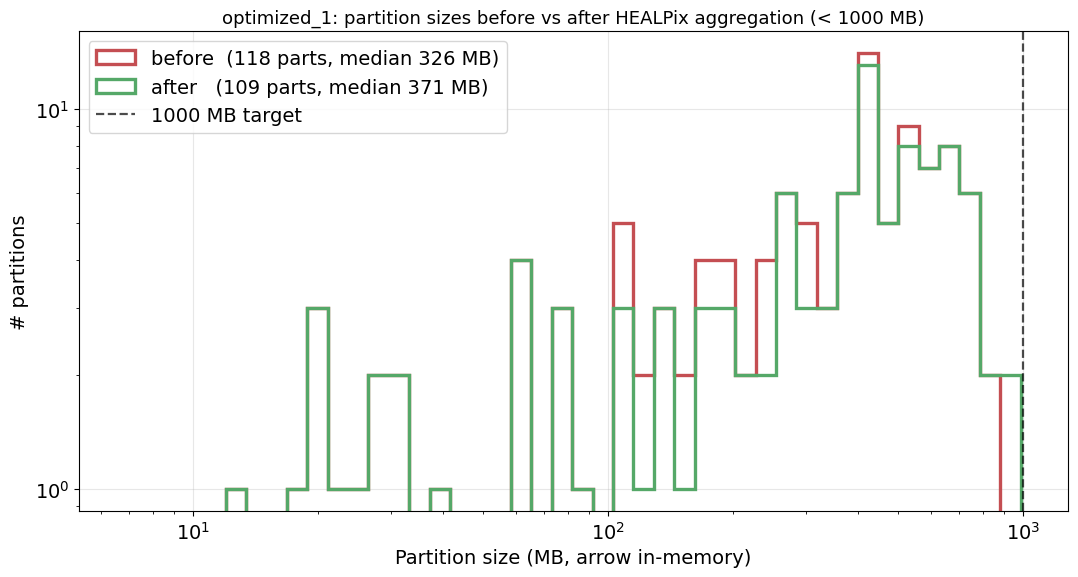

optimized_2: aggregation depth (HEALPix levels collapsed):
   1 level(s): 10 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  5 npix      4515 : depth 1     4 -> 1  (  905 MB, child orders up to 6)
     order  5 npix      4521 : depth 1     4 -> 1  (  979 MB, child orders up to 6)
     order  5 npix      4325 : depth 1     4 -> 1  (  980 MB, child orders up to 6)
     order  5 npix      4875 : depth 1     4 -> 1  (  922 MB, child orders up to 6)
     order  5 npix      4315 : depth 1     4 -> 1  (  905 MB, child orders up to 6)
     order  5 npix      4868 : depth 1     4 -> 1  (  917 MB, child orders up to 6)
     order  5 npix      4514 : depth 1     4 -> 1  (  996 MB, child orders up to 6)
     order  5 npix      4318 : depth 1     4 -> 1  (  967 MB, child orders up to 6)
     order  5 npix      4878 : depth 1     4 -> 1  (  893 MB, child orders up to 6)
     order  5 npix      4332 : depth 

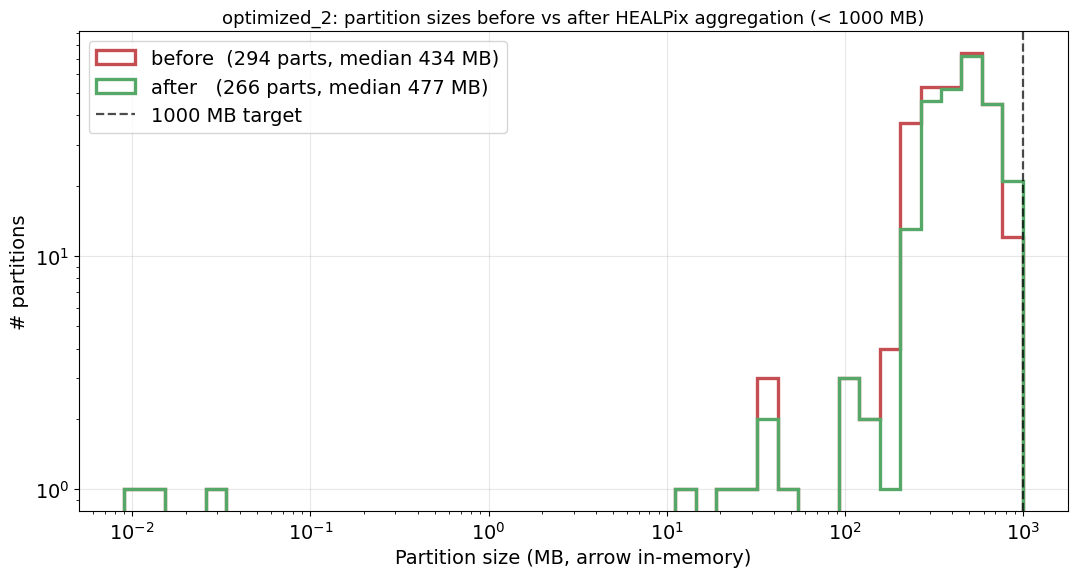

In [16]:
def aggregation_report(name, cat_dir, thresh_mb=MERGE_THRESH_MB, show=10):
    """Aggregation depth (HEALPix levels each merge collapses) + a before/after
    partition-size figure, in exact arrow in-memory MB. Equivalent to iterating
    single-level merges to convergence; depth >= 2 are the 'aggregate twice or
    more' cases.
    """
    order, npix, mb = partition_arrow_mb(cat_dir)  # mb = exact arrow in-memory MB
    maxo = int(order.max())

    total, leaves, maxchild = defaultdict(float), defaultdict(int), defaultdict(int)
    for o, p, m in zip(order.astype(int), npix.astype(int), mb):
        total[(o, p)] += m; leaves[(o, p)] += 1; maxchild[(o, p)] = o
    for o in range(maxo, 0, -1):
        for (oo, p) in [k for k in total if k[0] == o]:
            par = (o - 1, p >> 2)
            total[par] += total[(oo, p)]
            leaves[par] += leaves[(oo, p)]
            maxchild[par] = max(maxchild[par], maxchild[(oo, p)])

    mergeable = {k for k, t in total.items() if leaves[k] > 1 and t < thresh_mb}
    maximal = [k for k in mergeable if (k[0] - 1, k[1] >> 2) not in mergeable]
    depth = {k: maxchild[k] - k[0] for k in maximal}  # HEALPix levels collapsed

    # Before/after partition-size arrays: merged groups + untouched leaves.
    maxset = set(maximal)
    after = [total[k] for k in maximal]
    for o, p, m in zip(order.astype(int), npix.astype(int), mb):
        oo, pp, anc = o, p, None
        while oo > 0:
            oo, pp = oo - 1, pp >> 2
            if (oo, pp) in maxset:
                anc = True
                break
        if anc is None:
            after.append(m)
    after = np.array(after)

    dc = Counter(depth.values())
    twice = sum(v for d, v in dc.items() if d >= 2)
    print(f"{name}: aggregation depth (HEALPix levels collapsed):")
    for d in sorted(dc):
        print(f"   {d} level(s): {dc[d]:,} groups")
    print(f"   -> {twice:,} groups aggregate >=2 levels ('twice or more')")
    print(f"\n   deepest examples (parent order/npix : depth, #parts -> 1, size):")
    for o, p in sorted(maximal, key=lambda k: (depth[k], leaves[k]), reverse=True)[:show]:
        print(f"     order {o:>2d} npix {p:>9d} : depth {depth[(o, p)]}  {leaves[(o, p)]:>4d} -> 1  "
              f"({total[(o, p)]:5.0f} MB, child orders up to {maxchild[(o, p)]})")

    fig, ax = plt.subplots(figsize=(11, 6))
    bins = np.logspace(np.log10(min(mb.min(), after.min())),
                       np.log10(max(mb.max(), after.max())), 45)
    ax.hist(mb, bins=bins, histtype="step", lw=2.4, color="#C44E52",
            label=f"before  ({len(mb):,} parts, median {np.median(mb):.0f} MB)")
    ax.hist(after, bins=bins, histtype="step", lw=2.4, color="#55A868",
            label=f"after   ({len(after):,} parts, median {np.median(after):.0f} MB)")
    ax.axvline(thresh_mb, color="k", ls="--", lw=1.6, alpha=0.7, label=f"{thresh_mb:.0f} MB target")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Partition size (MB, arrow in-memory)")
    ax.set_ylabel("# partitions")
    ax.set_title(f"{name}: partition sizes before vs after HEALPix aggregation (< {thresh_mb:.0f} MB)",
                 fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

    return maximal, depth


for name, path in CATALOGS.items():
    _ = aggregation_report(name, path)

## One merge example, drawn as HEALPix tiles

Pick a single mergeable parent and draw every partition under it as its true HEALPix tile,
coloured/labelled by exact in-memory size (MB), inside the big red parent-pixel outline.
This shows concretely what "aggregate to a coarser order" means: tiles that together stay
under the 1 GB in-memory target and could collapse into the single enclosing tile. The
auto-picker prefers a mixed-order group and returns `None` with a message if a catalog has
nothing to merge.

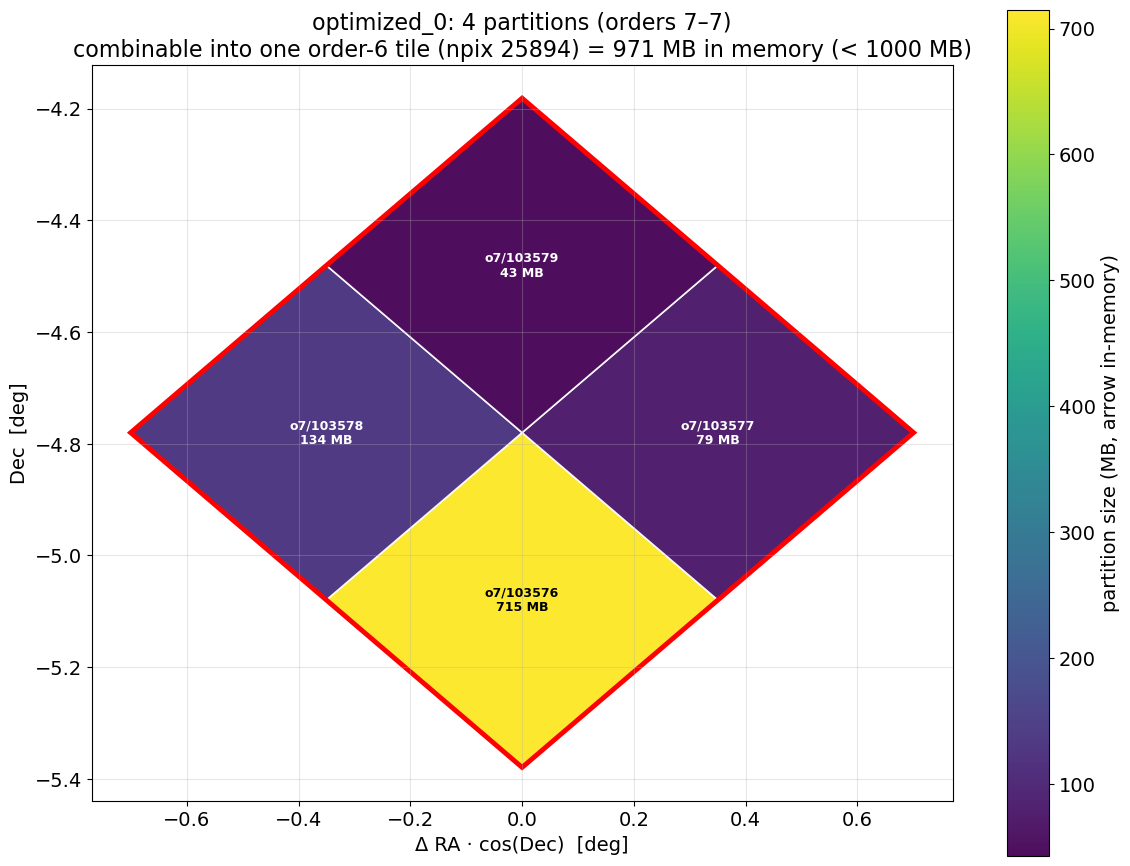

In [17]:
import matplotlib as mpl
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from cdshealpix.nested import vertices


def _children_under(order, npix, mb, po, pp):
    """All leaf partitions (order>=po) whose HEALPix ancestor at order po is pp."""
    sel = (order >= po) & ((npix >> (2 * (order - po))) == pp)
    return order[sel], npix[sel], mb[sel]


def plot_merge_example(name, cat_dir, thresh_mb=MERGE_THRESH_MB, parent=None,
                       want_children=(6, 18), label_below=9):
    """Draw all partitions under one mergeable parent as HEALPix tiles, coloured
    by exact in-memory size and labelled with order/npix + size (MB), inside the
    parent-pixel outline. Tiles at order >= `label_below` are left unlabelled
    (too small/crowded). If `parent` (order, npix) is None, auto-pick a
    mixed-order group with `want_children[0..1]` partitions, relaxing gracefully
    if none exists; returns None (with a message) if the catalog has no merge
    groups at all. Returns the chosen `(order, npix)`.
    """
    order, npix, mb = partition_arrow_mb(cat_dir)  # mb = exact arrow in-memory MB
    order = order.astype(int); npix = npix.astype(int)
    maxo = int(order.max())

    if parent is None:
        total, leaves, hi, lo = (defaultdict(float), defaultdict(int),
                                 defaultdict(int), defaultdict(lambda: 99))
        for o, p, m in zip(order, npix, mb):
            total[(o, p)] += m; leaves[(o, p)] += 1; hi[(o, p)] = o; lo[(o, p)] = o
        for o in range(maxo, 0, -1):
            for (oo, p) in [k for k in total if k[0] == o]:
                par = (o - 1, p >> 2)
                total[par] += total[(oo, p)]; leaves[par] += leaves[(oo, p)]
                hi[par] = max(hi[par], hi[(oo, p)]); lo[par] = min(lo[par], lo[(oo, p)])
        mergeable = {k for k, t in total.items() if leaves[k] > 1 and t < thresh_mb}
        maximal = [k for k in mergeable if (k[0] - 1, k[1] >> 2) not in mergeable]
        if not maximal:
            print(f"{name}: no merge groups under {thresh_mb:.0f} MB — nothing to draw.")
            return None
        cand = [k for k in maximal
                if want_children[0] <= leaves[k] <= want_children[1] and hi[k] > lo[k]]
        if not cand:  # small catalogs may lack big mixed-order groups — relax
            cand = [k for k in maximal if hi[k] > lo[k]] or list(maximal)
        # most distinct child orders, then fullest
        cand.sort(key=lambda k: (len(np.unique(_children_under(order, npix, mb, *k)[0])),
                                 total[k]), reverse=True)
        parent = cand[0]

    po, pp = parent
    co, cp, cm = _children_under(order, npix, mb, po, pp)
    merged = cm.sum()

    lon0, lat0 = healpix_to_lonlat(np.array([pp], np.uint64), np.uint8(po))
    lon0 = float(lon0.deg[0]); lat0 = float(lat0.deg[0]); cosd = np.cos(np.radians(lat0))

    def poly_xy(o, p):
        lon, lat = vertices(np.array([p], np.uint64), np.uint8(o))
        lon = np.array(lon.deg)[0]; lat = np.array(lat.deg)[0]
        lon = ((lon - lon0 + 180) % 360) - 180
        return np.column_stack([lon * cosd, lat])

    norm = mpl.colors.Normalize(cm.min(), cm.max())
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(figsize=(12, 11))
    pats = []
    for o, p, m in zip(co, cp, cm):
        xy = poly_xy(o, p); pats.append(Polygon(xy, closed=True))
        if o < label_below:  # deepest tiles are too small/crowded to label
            ax.text(xy[:, 0].mean(), xy[:, 1].mean(), f"o{o}/{p}\n{m:.0f} MB",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if norm(m) < 0.6 else "black")
    pc = PatchCollection(pats, cmap=cmap, norm=norm, edgecolor="white", lw=1.2, alpha=0.95)
    pc.set_array(cm); ax.add_collection(pc)
    ax.add_patch(Polygon(poly_xy(po, pp), closed=True, fill=False, edgecolor="red", lw=3.5))
    fig.colorbar(pc, ax=ax, shrink=0.8).set_label("partition size (MB, arrow in-memory)")
    ax.set_xlabel("Δ RA · cos(Dec)  [deg]")
    ax.set_ylabel("Dec  [deg]")
    ax.set_title(f"{name}: {len(cm)} partitions (orders {co.min()}–{co.max()})\n"
                 f"combinable into one order-{po} tile (npix {pp}) = {merged:.0f} MB "
                 f"in memory (< {thresh_mb:.0f} MB)")
    ax.autoscale_view(); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()
    return parent


example_parent = plot_merge_example("optimized_0", CATALOGS["optimized_0"])

### Where that region sits on the full partition map

The same `example_parent` pixel marked (red tile) on the zoomed optimized_0 partition map,
so the merge example can be located in context within the footprint.

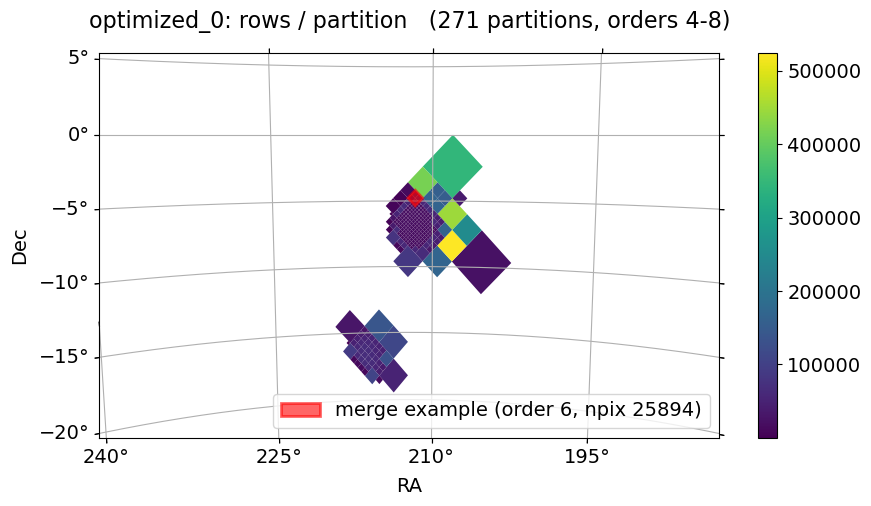

In [18]:
_ = plot_partition_map("optimized_0", CATALOGS["optimized_0"],
                       by="rows", mark=example_parent)